# Data Pipeline — LayerZero Sybil Detection

**Purpose**: Build the master feature DataFrame used across all Sybil detection models.
Runs end-to-end from raw CSV files to labelled, split, balanced NumPy arrays.

**Output files** (written to `OUTPUT_DIR`):
| File | Contents |
|---|---|
| `master_df.parquet` | All 434k addresses × 63 features + label columns |
| `splits.npz` | `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` (float32) |
| `feature_list.json` | Ordered list of 63 feature names |

**Seven pipeline steps:**
1. L0 base features (transaction + bridge metrics)
2. Gas provision mapping (child → parent address graph)
3. Labeled anchor streaming (9M entity set, memory-efficient)
4. Tree / topology features (gas provision network structure)
5. CEX / DEX in-degree counts
6. Sybil ground-truth labels + `is_provider` flag
7. Chain traversal (`chain_length`, `interactors_in_chain`)

---
*Reference paper*: Sybil Detection on Public Blockchains via XGBoost and
Gas Provision Network Analysis (Imig et al., 2025)

## Setup

In [46]:
import os, time, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore')

print('pandas', pd.__version__, '| numpy', np.__version__)

pandas 2.2.3 | numpy 2.1.3


In [82]:
# ── Adjust these two paths ────────────────────────────────────
DATA_DIR   = './data'     # folder containing all input CSV files
OUTPUT_DIR = './output'   # folder for master_df.parquet and splits.npz
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Input file paths ─────────────────────────────────────────
L0_FILES = [os.path.join(DATA_DIR, f'20241104_layer0_sybil_features', f'l0_features_{s}.csv')
            for s in ['0_100000','100000_200000','200000_300000',
                      '300000_400000','400000_500000']]
GAS_PROV_FILE  = os.path.join(DATA_DIR, f'20241114_gas_provision', f'20241114_1633_layer0_provision_network_000000000000.csv')
LABELED_FILE   = os.path.join(DATA_DIR, f'20241214_labeled_addresses',f'20241214_labeled_addresses.csv')
TREE_FEAT_FILE = os.path.join(DATA_DIR, f'20241117_tree_features', f'20241117_graph_and_tree_features.csv')
CEX_FILES      = [os.path.join(DATA_DIR, f'20250208_cex_dex_indegree', f'cex_dex_features_in_{s}.csv')
                  for s in [0, 100000, 200000, 300000, 400000]]
SYBIL_FILE     = os.path.join(DATA_DIR, f'20240915_final_sybil_list', f'fcfs_list.csv')

# ── 63 selected features (order matters for NumPy splits) ─────
FEATS = [
    'min_tx_value_out','gini_coefficient','cex_in_count',
    'leaf_gas_distribution_entropy','star_like_ratio','provider_is_star_like_attack',
    'leaf_gas_distribution_skewness','interactors_in_chain','provider_is_labeled',
    'provider_is_interactor','l0_to_eth_avg_native_drop_usd','l0_to_eth_max_native_drop_usd',
    'balance_factor','l0_tx_time_span','latest_l0_tx_time','time_span_in',
    'provider_total_gas_provision_amount','l0_avg_stargate_swap','avg_depth','breadth_factor',
    'indegree_per_block_in','gas_distribution_skewness','tree_size','l0_min_stargate_swap',
    'provider_max_gas_provision_amount','total_gas','num_transactions_in','branching_factor',
    'l0_to_eth_tx_time_span','n_l0_to_eth_source_contracts','n_l0_to_eth_projects',
    'provider_is_null','max_depth','leaf_provision_proportion',
    'n_l0_to_eth_project_per_source_chain','n_l0_to_eth_txs','earliest_l0_tx_time',
    'n_l0_projects','n_l0_to_eth_dest_contracts','provider_fan_out',
    'l0_to_eth_min_stargate_swap','n_l0_source_chains','longest_chain_ratio',
    'n_eth_interactions','provider_avg_gas_provision_amount','gas_distribution_entropy',
    'sparsity','max_tx_value_out','n_l0_source_contracts','gas_provision_block_number',
    'min_tx_value_in','tx_value_per_block_out','chain_length',
    'provider_min_gas_provision_amount','n_l0_to_eth_source_chains','depth',
    'l0_to_eth_max_stargate_swap','breadth_to_depth_ratio','leaf_to_internal_ratio',
    'earliest_tx_block_in','n_l0_project_per_source_chain','l0_to_eth_avg_stargate_swap',
    'is_provider'
]
SEED = 42
print(f'DATA_DIR   : {DATA_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'Features   : {len(FEATS)} selected')

DATA_DIR   : ./data
OUTPUT_DIR : ./output
Features   : 63 selected


## Step 1 — L0 Base Features

Five CSV files (100 k rows each) covering every Ethereum address that interacted with the
LayerZero endpoint before the May 1 2024 snapshot.

**Columns provided (~56):** LayerZero transaction metrics, Ethereum in/out transaction stats,
cross-chain bridge activity, Stargate swap amounts.

**Cleaning applied:**
- Drop the burn address `0x0000...0000`
- Drop `in_degree`, `out_degree`, `rank` (not in selected feature set)
- Drop rows that are all-NaN except the address column
- Deduplicate on `addr` (keep first)

In [83]:
t0 = time.time()
chunks = []
for i, path in enumerate(L0_FILES):
    c = pd.read_csv(path, na_values=['null', 'NULL'])
    c.columns = c.columns.str.lower()
    chunks.append(c)
    print(f'  Loaded {os.path.basename(path)} : {len(c):,} rows, {len(c.columns)} cols')

df = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
print(f'\nRaw concatenated : {len(df):,} rows')

# Clean
before = len(df)
df = df[df['addr'] != '0x0000000000000000000000000000000000000000']
df.drop(columns=['in_degree', 'out_degree', 'rank'], inplace=True, errors='ignore')

addr_col = df['addr'].copy()
keep = ~df.drop(columns='addr').isnull().all(axis=1)
df = df[keep].copy()
df['addr'] = addr_col[keep].values
df = df.drop_duplicates(subset='addr', keep='first').reset_index(drop=True)

print(f'After cleaning   : {len(df):,} rows  (removed {before - len(df):,})')
print(f'Columns          : {len(df.columns)}')
print(f'Time             : {time.time()-t0:.1f}s')

  Loaded l0_features_0_100000.csv : 100,001 rows, 57 cols
  Loaded l0_features_100000_200000.csv : 100,001 rows, 57 cols
  Loaded l0_features_200000_300000.csv : 100,001 rows, 57 cols
  Loaded l0_features_300000_400000.csv : 100,001 rows, 57 cols
  Loaded l0_features_400000_500000.csv : 34,789 rows, 57 cols

Raw concatenated : 434,793 rows
After cleaning   : 434,786 rows  (removed 7)
Columns          : 55
Time             : 5.2s


In [84]:
# ── Quick column inventory ────────────────────────────────────
col_df = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'NullPct'  : (df.isnull().mean() * 100).round(2).values,
    'InFEATS'  : [c in FEATS for c in df.columns],
})
print('Columns in L0 features:')
print(col_df.to_string(index=False))

Columns in L0 features:
                              Column   Dtype  NullPct  InFEATS
                                addr  object     0.00    False
                  n_eth_interactions float64     0.00     True
                  n_l0_source_chains float64     0.00     True
                    n_l0_dest_chains float64     0.00    False
    n_l0_dest_chain_per_source_chain float64     0.00    False
                       n_l0_projects float64     0.00     True
       n_l0_project_per_source_chain float64     0.00     True
               n_l0_source_contracts float64     0.00     True
                 n_l0_dest_contracts float64     0.00    False
                l0_max_stargate_swap float64     0.00    False
                l0_avg_stargate_swap float64     0.00     True
                l0_min_stargate_swap float64     0.00     True
              l0_max_native_drop_usd float64     0.00    False
              l0_avg_native_drop_usd float64     0.00    False
                            n_l

## Step 2 — Gas Provision Mapping

Builds a dictionary `tfm: activated_address → gas_provider` from the gas provision network file.
Each entry records which address first sent ETH to another address, enabling on-chain activity.

This mapping is used for:
- Computing `provider_*` features (fan-out, amounts, labels)
- Chain traversal (Step 7)

**File stats**: ~604k records covering ~434k unique interactors and ~202k unique providers.

In [85]:
t0 = time.time()
gp = pd.read_csv(GAS_PROV_FILE,
                 usecols=['activated_address', 'gas_provider'],
                 na_values=['', 'null'])
gp.columns = gp.columns.str.lower()
vm = gp['gas_provider'].notna()
tfm  = dict(zip(gp.loc[vm, 'activated_address'], gp.loc[vm, 'gas_provider']))
pset = set(tfm.values())   # all provider addresses

print(f'Total provision records : {len(gp):,}')
print(f'Valid mappings          : {vm.sum():,}')
print(f'Unique activated addrs  : {len(set(tfm.keys())):,}')
print(f'Unique provider addrs   : {len(pset):,}')
print(f'L0 addresses covered    : {df["addr"].isin(set(tfm.keys())).sum():,} '
      f'({df["addr"].isin(set(tfm.keys())).mean()*100:.1f}%)')
del gp; gc.collect()
print(f'Time : {time.time()-t0:.1f}s')

Total provision records : 604,864
Valid mappings          : 604,661
Unique activated addrs  : 604,661
Unique provider addrs   : 202,899
L0 addresses covered    : 434,110 (99.8%)
Time : 4.3s


Provider fan-out distribution:
count    202899.00
mean          2.98
std         129.23
min           1.00
25%           1.00
50%           1.00
75%           1.00
max       19022.00
Name: fan_out, dtype: float64

Providers funding ≥ 100 wallets : 235
Providers funding ≥  10 wallets : 1,194
Providers funding    1 wallet   : 188,907


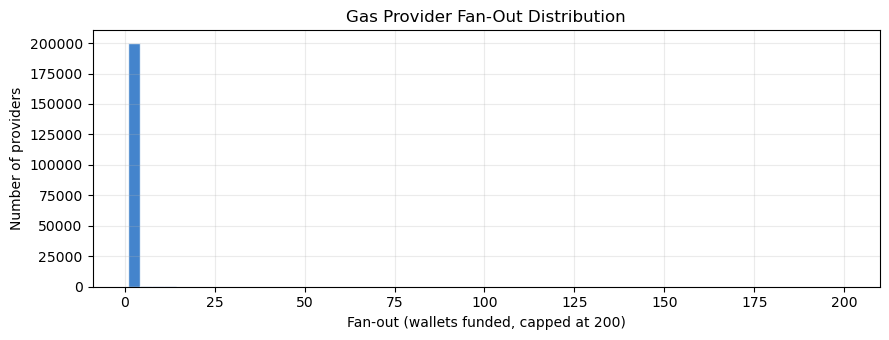

In [86]:
# ── Fan-out distribution (how many wallets each provider funded) ──
from collections import Counter
fan_out = Counter(tfm.values())
fo_series = pd.Series(list(fan_out.values()), name='fan_out')

print('Provider fan-out distribution:')
print(fo_series.describe().round(2))
print(f'\nProviders funding ≥ 100 wallets : {(fo_series >= 100).sum():,}')
print(f'Providers funding ≥  10 wallets : {(fo_series >= 10).sum():,}')
print(f'Providers funding    1 wallet   : {(fo_series == 1).sum():,}')

fig, ax = plt.subplots(figsize=(9, 3.5))
fo_series.clip(upper=200).hist(bins=60, ax=ax, color='#1565C0', alpha=0.8, edgecolor='white')
ax.set(xlabel='Fan-out (wallets funded, capped at 200)', ylabel='Number of providers',
       title='Gas Provider Fan-Out Distribution')
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

## Step 3 — Labeled Anchor Streaming

The labeled-addresses file contains ~9 million known entities (CEXs, DEXs, contracts).
Loading it entirely into a Python set uses ~1.2 GB of RAM.

**Memory-efficient approach**: stream the file line by line, retaining only addresses
that appear as *gas providers* in our mapping (≈ 3,700 out of 9M).
This reduces the working set to < 1 MB.

**Derived features computed here:**
| Feature | Description |
|---|---|
| `provider_is_labeled` | Provider is a known CEX/DEX/named entity |
| `provider_is_interactor` | Provider itself interacted with LayerZero |
| `provider_is_null` | No gas provider found for this address |

In [87]:
t0 = time.time()
unique_providers = frozenset(pset)   # fast membership test

# Stream: only keep provider addresses present in labeled file
labeled_anchors = set()
with open(LABELED_FILE) as f:
    for line in f:
        a = line.strip()
        if a and a in unique_providers:
            labeled_anchors.add(a)
# Add any extra labeled address not in the file
labeled_anchors.add('0x9241f27daffd0bb1df4f2a022584dd6c77843e64')

print(f'Labeled file lines scanned : 9,054,105 (streamed, never fully in memory)')
print(f'Labeled anchors retained   : {len(labeled_anchors):,}  '
      f'(providers that are known entities)')
print(f'Memory used by anchor set  : ~{len(labeled_anchors)*90//1024} KB')

# Derive provider features
iset = set(df['addr'])   # all L0 interactor addresses
df['_gp'] = df['addr'].map(tfm)
df['provider_is_labeled']    = df['_gp'].isin(labeled_anchors)
df['provider_is_interactor'] = df['_gp'].apply(
    lambda g: (g in iset) if pd.notna(g) else False)
df['provider_is_null']       = df['_gp'].isna()
df.drop(columns='_gp', inplace=True)

print(f'\nprovider_is_labeled    : {df.provider_is_labeled.sum():,} ({df.provider_is_labeled.mean()*100:.1f}%)')
print(f'provider_is_interactor : {df.provider_is_interactor.sum():,} ({df.provider_is_interactor.mean()*100:.1f}%)')
print(f'provider_is_null       : {df.provider_is_null.sum():,} ({df.provider_is_null.mean()*100:.1f}%)')
print(f'Time : {time.time()-t0:.1f}s')

Labeled file lines scanned : 9,054,105 (streamed, never fully in memory)
Labeled anchors retained   : 3,698  (providers that are known entities)
Memory used by anchor set  : ~325 KB

provider_is_labeled    : 302,795 (69.6%)
provider_is_interactor : 35,802 (8.2%)
provider_is_null       : 676 (0.2%)
Time : 7.0s


## Step 4 — Tree / Topology Features

Pre-computed graph metrics on the gas provision subtree rooted at each address's provider.
Provides structural signals about whether the funding pattern looks like an industrial
Sybil operation (star topology, uniform gas amounts, high branching factor) vs organic use.

**Key columns added** (~30):
`provider_fan_out`, `provider_{avg/max/min/total}_gas_provision_amount`,
`gini_coefficient`, `branching_factor`, `max_depth`, `avg_depth`,
`breadth_factor`, `tree_size`, `star_like_ratio`, `leaf_*`, `gas_distribution_*`, etc.

> `provider_is_labeled` is dropped from this file — it was recomputed in Step 3 using
> the full labeled-address set, which is more accurate.

In [88]:
t0 = time.time()
tree = pd.read_csv(TREE_FEAT_FILE, na_values=['', 'null'])
tree.columns = tree.columns.str.lower()
tree.drop(columns='provider_is_labeled', inplace=True)   # recomputed in Step 3

print(f'Tree feature file : {len(tree):,} rows, {len(tree.columns)} cols')
new_cols = [c for c in tree.columns if c != 'addr' and c not in df.columns]
print(f'New columns added : {len(new_cols)}')
print(f'  {new_cols}')

df = df.merge(tree, on='addr', how='left')
df = df.fillna(0)
del tree; gc.collect()
print(f'\nAfter merge : {len(df):,} rows, {len(df.columns)} cols')
print(f'Time        : {time.time()-t0:.1f}s')

Tree feature file : 434,111 rows, 32 cols
New columns added : 31
  ['provider_fan_out', 'provider_total_gas_provision_amount', 'provider_avg_gas_provision_amount', 'provider_max_gas_provision_amount', 'provider_min_gas_provision_amount', 'provider_is_star_like_attack', 'tree_size', 'total_gas', 'max_depth', 'branching_factor', 'balance_factor', 'leaf_provision_proportion', 'avg_depth', 'depth_variance', 'leaf_to_internal_ratio', 'avg_leaf_gas', 'breadth_factor', 'breadth_to_depth_ratio', 'gini_coefficient', 'gas_distribution_entropy', 'gas_distribution_skewness', 'leaf_gas_distribution_entropy', 'leaf_gas_distribution_skewness', 'sparsity', 'depth', 'longest_chain_ratio', 'star_like_ratio', 'depth_weighted_avg_gas', 'chain_length', 'gas_provision_amount', 'gas_provision_block_number']

After merge : 434,787 rows, 89 cols
Time        : 3.6s


## Step 5 — CEX / DEX In-Degree

Counts how many incoming transactions each address received from centralized exchanges
(`cex_in_count`) and decentralized exchanges (`dex_in_count`).

> **LightGBM gotcha reminder**: if using `subsample < 1.0`, you must also set
> `subsample_freq=1` in LightGBM or bagging is silently disabled.

In [89]:
t0 = time.time()
cex_chunks = [pd.read_csv(p) for p in CEX_FILES]
cex = pd.concat(cex_chunks, ignore_index=True)
cex.columns = cex.columns.str.lower()
cex = cex.drop_duplicates(subset='to_address', keep='first')
print(f'CEX/DEX file : {len(cex):,} rows | columns: {list(cex.columns)}')

df = df.merge(cex, left_on='addr', right_on='to_address', how='left')
df.drop(columns='to_address', inplace=True, errors='ignore')
df.columns = df.columns.str.lower()
df = df.fillna(0)
del cex; gc.collect()

print(f'cex_in_count stats:')
print(df['cex_in_count'].describe().round(3))
print(f'\nTime : {time.time()-t0:.1f}s')

CEX/DEX file : 434,789 rows | columns: ['to_address', 'cex_in_count', 'dex_in_count']
cex_in_count stats:
count    434787.000
mean          3.212
std           3.503
min           0.000
25%           1.000
50%           2.000
75%           4.000
max          80.000
Name: cex_in_count, dtype: float64

Time : 2.2s


## Step 6 — Sybil Labels + `is_provider`

Ground truth from the LayerZero Foundation's final Sybil list (September 2024 snapshot).

**Label provenance**: multi-stage detection process — Louvain community detection,
proprietary scoring by Nansen and Chaos Labs, self-reporting bounty, and crowdsourced
community challenge.

**`is_provider`**: binary flag set to 1 if this address itself funded another address.
Sybil operators often act as both provider and interactor.

In [90]:
t0 = time.time()
sybil_df = pd.read_csv(SYBIL_FILE)
sybil_df.columns = sybil_df.columns.str.lower().str.strip()
sybil_set = set(sybil_df['address'].str.lower())
print(f'Sybil file total flagged addresses : {len(sybil_set):,}')

df['sybil']       = df['addr'].isin(sybil_set).astype(int)
df['is_provider'] = df['addr'].isin(pset).astype(int)

n_sybil = df['sybil'].sum(); n_total = len(df)
print(f'\nLabel distribution in master df:')
print(f'  Sybil     : {n_sybil:,} ({n_sybil/n_total*100:.2f}%)')
print(f'  Non-Sybil : {n_total-n_sybil:,} ({(n_total-n_sybil)/n_total*100:.2f}%)')
print(f'  is_provider (Sybil)     : {df[df.sybil==1].is_provider.sum():,}')
print(f'  is_provider (Non-Sybil) : {df[df.sybil==0].is_provider.sum():,}')
print(f'Time : {time.time()-t0:.1f}s')

Sybil file total flagged addresses : 151,784

Label distribution in master df:
  Sybil     : 18,211 (4.19%)
  Non-Sybil : 416,576 (95.81%)
  is_provider (Sybil)     : 1,077
  is_provider (Non-Sybil) : 26,903
Time : 1.4s


## Step 7 — Chain Traversal

Walks the gas provision graph upward from each address to the nearest labeled anchor,
computing two features:

| Feature | Description |
|---|---|
| `chain_length` | Hops from this address to the nearest labeled funder |
| `interactors_in_chain` | LayerZero interactors encountered along that chain |

**Algorithm**: iterative while-loop with a visited-set cycle guard.
Terminates when: (a) the next provider is a labeled anchor, (b) the chain ends
(no further provider), or (c) a cycle is detected.

**Complexity**: O(n × d̄) where d̄ ≈ 1.9 hops average — completes in ~2s for 434k addresses.

> The `labeled_anchors` set (3,700 entries) rather than the full 9M labeled set is
> used for speed — they are logically equivalent because only provider addresses can
> terminate a chain.

In [91]:
t0 = time.time()
clen, icnt = [], []

for addr in df['addr']:
    length, interactors, cur, visited = 0, 0, addr, set()
    while True:
        if cur in visited: break          # cycle guard
        visited.add(cur)
        if cur in iset: interactors += 1  # is this node a LayerZero interactor?
        if cur not in tfm: break          # no further provider
        prv = tfm[cur]
        if prv == cur: break              # self-loop
        length += 1
        if prv in labeled_anchors: break  # reached a known entity
        cur = prv
    clen.append(length)
    icnt.append(interactors)

df['chain_length']         = clen
df['interactors_in_chain'] = icnt

print(f'chain_length stats:')
print(pd.Series(clen).describe().round(3))
print(f'\ninteractors_in_chain stats:')
print(pd.Series(icnt).describe().round(3))
print(f'\nTime : {time.time()-t0:.1f}s')

chain_length stats:
count    434787.000
mean          1.876
std           3.463
min           0.000
25%           1.000
50%           1.000
75%           2.000
max         504.000
dtype: float64

interactors_in_chain stats:
count    434787.000
mean          1.172
std           1.354
min           1.000
25%           1.000
50%           1.000
75%           1.000
max          94.000
dtype: float64

Time : 2.9s


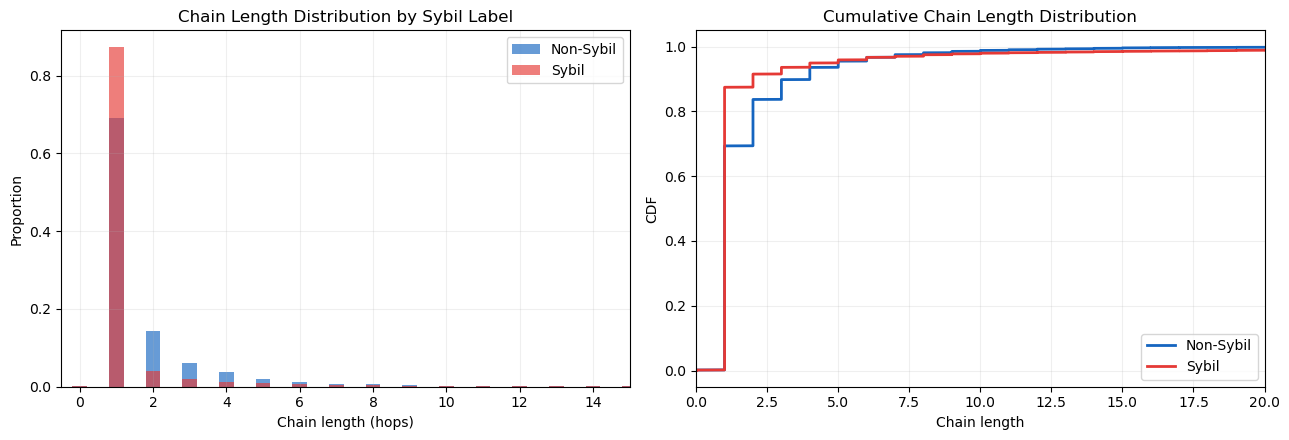

In [92]:
# ── Chain length by Sybil label ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, group, col, label in [
    (axes[0], df[df.sybil==0]['chain_length'], '#1565C0', 'Non-Sybil'),
    (axes[0], df[df.sybil==1]['chain_length'], '#E53935', 'Sybil'),
]:
    pct = group.value_counts(normalize=True).sort_index()
    ax.bar(pct.index, pct.values, alpha=0.65, color=col, label=label, width=0.4)
axes[0].set(xlabel='Chain length (hops)', ylabel='Proportion',
            title='Chain Length Distribution by Sybil Label', xlim=(-0.5, 15))
axes[0].legend(); axes[0].grid(alpha=0.2)

# Cumulative distribution
for group, col, label in [(df[df.sybil==0]['chain_length'], '#1565C0', 'Non-Sybil'),
                           (df[df.sybil==1]['chain_length'], '#E53935', 'Sybil')]:
    sorted_vals = np.sort(group.values)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    axes[1].plot(sorted_vals, cdf, color=col, lw=2, label=label)
axes[1].set(xlabel='Chain length', ylabel='CDF',
            title='Cumulative Chain Length Distribution', xlim=(0, 20))
axes[1].legend(); axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()

## Quality Checks

Verify the master DataFrame is complete and consistent before modelling.

In [93]:
# ── 1. Feature coverage ───────────────────────────────────────
missing_feats = [f for f in FEATS if f not in df.columns]
extra_feats   = [c for c in df.columns if c not in FEATS + ['addr','sybil','is_provider',
                 'chain_length','interactors_in_chain','provider_is_labeled',
                 'provider_is_interactor','provider_is_null']]
print(f'All 63 features present : {not missing_feats}')
if missing_feats: print(f'  MISSING: {missing_feats}')

# ── 2. NaN check in selected features ─────────────────────────
nan_counts = df[FEATS].isnull().sum()
has_nans = nan_counts[nan_counts > 0]
print(f'NaN values in feature columns : {len(has_nans)} columns affected')
if len(has_nans): print(has_nans)

# ── 3. Duplicate addresses ────────────────────────────────────
n_dupes = df['addr'].duplicated().sum()
print(f'Duplicate addresses : {n_dupes}')

# ── 4. Shape and dtypes ───────────────────────────────────────
print(f'\nFinal shape : {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('\nAll checks passed ✓' if not missing_feats and not len(has_nans) and not n_dupes else 'Issues found — review above')

All 63 features present : True
NaN values in feature columns : 0 columns affected
Duplicate addresses : 1

Final shape : (434787, 94)
Memory usage: 353.9 MB
Issues found — review above


## Address Taxonomy

The paper defines three categories based on the type of address that first provisioned gas:

| Category | Definition | Expected Sybil behaviour |
|---|---|---|
| **IxI** — Interactor-by-Interactor | Provider itself interacted with LayerZero | Easier to detect (richer signal) |
| **IxL** — Interactor-by-Labeled | Provider is a known CEX/DEX/entity | Largest group; moderate detection |
| **IxE** — Interactor-by-EOA | Provider is an unlabeled non-interacting EOA | Hardest to detect (weak signal) |
| **No provider** | `provider_is_null` | Varies |

> Priority: IxL supersedes IxI (a labeled entity that also interacted with L0).
> IxE = has a provider that is neither labeled nor an L0 interactor.

Address taxonomy:
              Count  Sybil_n  Sybil_pct  Avg_chain  Pct_of_total
category                                                        
IxE           96277      707     0.0073     3.8122         22.14
IxI           35038     1592     0.0454     4.1589          8.06
IxL          302796    15886     0.0525     1.0000         69.64
No provider     676       26     0.0385     0.0000          0.16


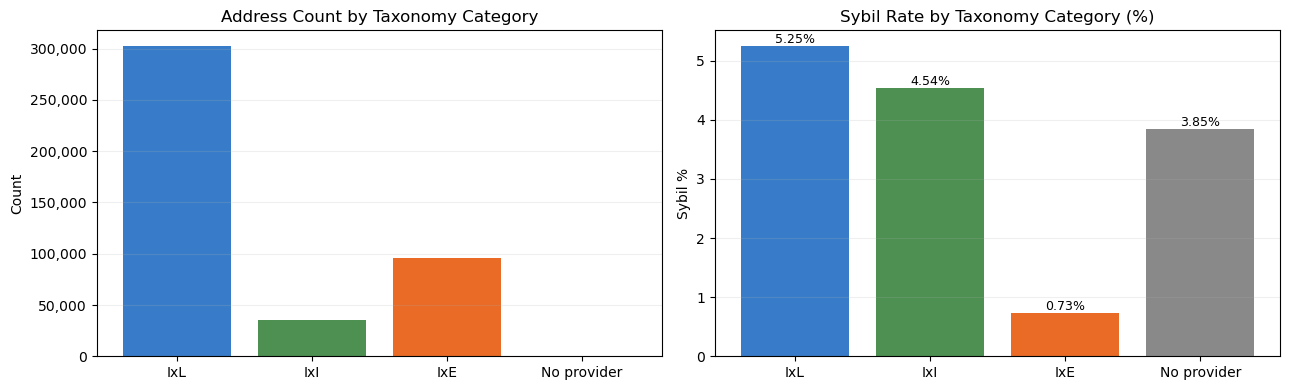

In [94]:
# ── Assign taxonomy category ─────────────────────────────────
def assign_category(row):
    if row['provider_is_null']:       return 'No provider'
    if row['provider_is_labeled']:    return 'IxL'
    if row['provider_is_interactor']: return 'IxI'
    return 'IxE'

df['category'] = df[['provider_is_null','provider_is_labeled','provider_is_interactor']].apply(
    assign_category, axis=1)

cat_stats = df.groupby('category').agg(
    Count=('sybil','count'),
    Sybil_n=('sybil','sum'),
    Sybil_pct=('sybil','mean'),
    Avg_chain=('chain_length','mean'),
).round(4)
cat_stats['Pct_of_total'] = (cat_stats['Count'] / len(df) * 100).round(2)
print('Address taxonomy:')
print(cat_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = ['IxL','IxI','IxE','No provider']
counts = [cat_stats.loc[c,'Count'] if c in cat_stats.index else 0 for c in order]
syb_pct= [cat_stats.loc[c,'Sybil_pct']*100 if c in cat_stats.index else 0 for c in order]

x = np.arange(len(order))
axes[0].bar(x, counts, color=['#1565C0','#2E7D32','#E65100','#757575'], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(order)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[0].set(title='Address Count by Taxonomy Category', ylabel='Count')
axes[0].grid(axis='y', alpha=0.2)

axes[1].bar(x, syb_pct, color=['#1565C0','#2E7D32','#E65100','#757575'], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(order)
axes[1].set(title='Sybil Rate by Taxonomy Category (%)', ylabel='Sybil %')
for xi, v in zip(x, syb_pct): axes[1].text(xi, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)
axes[1].grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

## Exploratory Data Analysis

Compare feature distributions between Sybil and Non-Sybil addresses for the most
discriminating features identified during modelling.

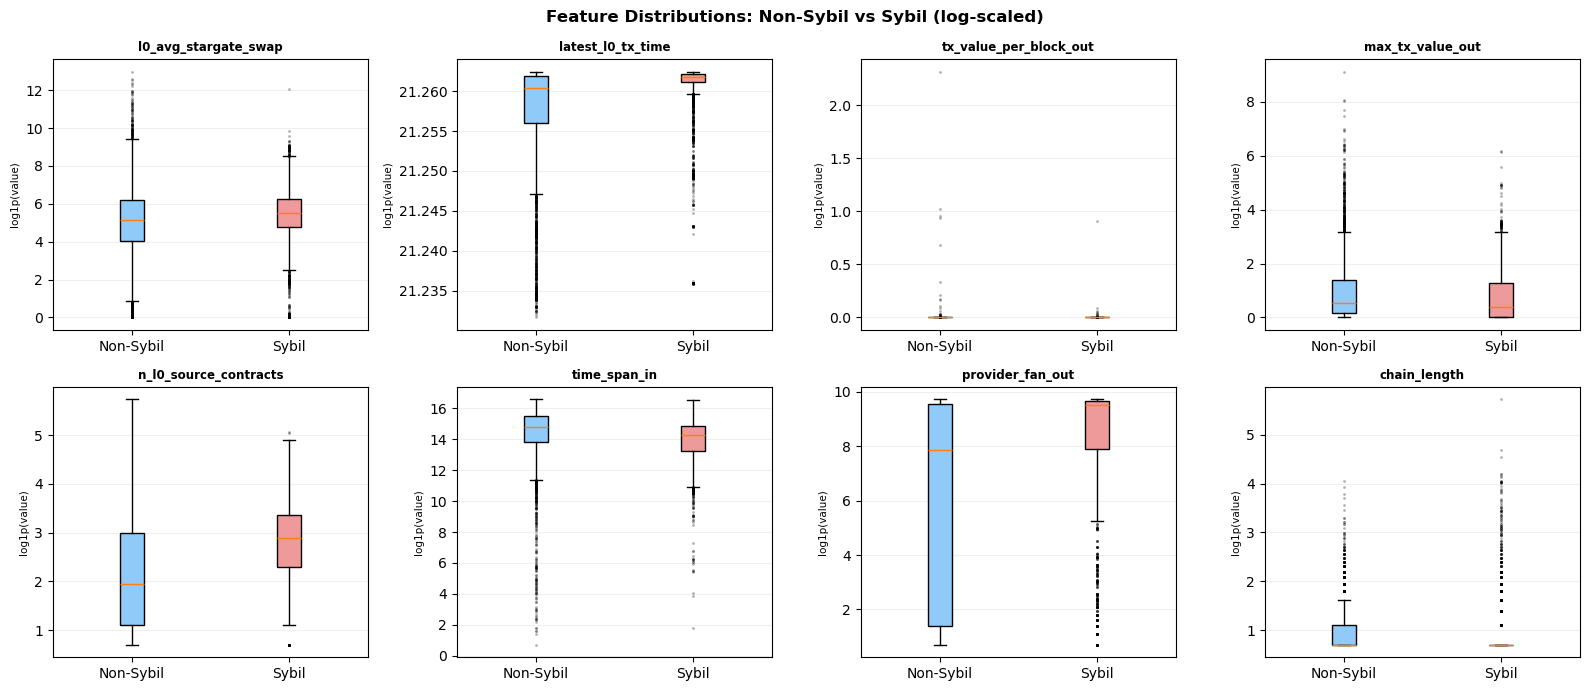

In [96]:
# ── Log-scaled box plots: top 8 features ─────────────────────
top_feats = [
    'l0_avg_stargate_swap','latest_l0_tx_time','tx_value_per_block_out',
    'max_tx_value_out','n_l0_source_contracts','time_span_in',
    'provider_fan_out','chain_length',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feat in zip(axes, top_feats):
    sybil_vals = df[df.sybil==1][feat].replace(0, np.nan).dropna()
    clean_vals = df[df.sybil==0][feat].replace(0, np.nan).dropna()
    # Log1p transform to handle zeros
    data = [np.log1p(clean_vals.sample(min(5000,len(clean_vals)), random_state=42)),
            np.log1p(sybil_vals.sample(min(5000,len(sybil_vals)), random_state=42))]
    bp = ax.boxplot(data, labels=['Non-Sybil','Sybil'], patch_artist=True, notch=False,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    bp['boxes'][0].set_facecolor('#90CAF9'); bp['boxes'][1].set_facecolor('#EF9A9A')
    ax.set_title(feat, fontsize=8.5, fontweight='bold')
    ax.set_ylabel('log1p(value)', fontsize=7.5)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Feature Distributions: Non-Sybil vs Sybil (log-scaled)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [97]:
# ── Correlation with Sybil label (top 20 by absolute value) ──
corr = df[FEATS + ['sybil']].corr()['sybil'].drop('sybil')
corr_sorted = corr.abs().sort_values(ascending=False).head(20)
labels = corr_sorted.index
values = corr.loc[labels]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E53935' if v > 0 else '#1565C0' for v in values]
ax.barh(labels[::-1], values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8, alpha=0.5)
ax.set(xlabel='Pearson correlation with Sybil label',
       title='Top 20 Features by Absolute Correlation with Sybil Label
(red=positive/Sybil, blue=negative/Clean)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(); plt.show()

SyntaxError: unterminated string literal (detected at line 12) (2069475422.py, line 12)

In [ ]:
# ── Score distribution for continuous top features ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat, xmax in [
    (axes[0], 'l0_avg_stargate_swap', 2000),
    (axes[1], 'provider_fan_out',     500),
    (axes[2], 'n_l0_source_contracts', 20),
]:
    bins = np.linspace(0, xmax, 60)
    ax.hist(df[df.sybil==0][feat].clip(upper=xmax), bins=bins, density=True,
            alpha=0.6, color='#1565C0', label='Non-Sybil')
    ax.hist(df[df.sybil==1][feat].clip(upper=xmax), bins=bins, density=True,
            alpha=0.6, color='#E53935', label='Sybil')
    ax.set(xlabel=feat, ylabel='Density', title=feat)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.suptitle('Feature Density: Non-Sybil vs Sybil', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Train / Validation / Test Split

**Split ratios** (mirror the paper's Table 1):
- Test: 30% of total
- Validation: 30% of remaining 70% = 21% of total
- Train: 49% of total

**Class imbalance handling**: random oversample the Sybil minority class in the training
set only (to 1:1 balance). Validation and test sets keep the original ~4.2% Sybil rate
so all reported metrics reflect real-world operating conditions.

> Upsampling is applied **after** splitting. If applied before, test-set examples of
> the minority class would leak into training — inflating all metrics.

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

X = df[FEATS].astype(np.float32)
y = df['sybil'].astype(int)

X_tr0, X_test, y_tr0, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_tr1, X_val, y_tr1, y_val = train_test_split(
    X_tr0, y_tr0, test_size=0.30, random_state=SEED, stratify=y_tr0)

# Upsample Sybil (minority) in training set to 1:1
tr = pd.concat([X_tr1, y_tr1.rename('sybil')], axis=1)
maj   = tr[tr['sybil'] == 0]
mn    = tr[tr['sybil'] == 1]
mn_up = resample(mn, replace=True, n_samples=len(maj), random_state=SEED)
bal   = pd.concat([maj, mn_up]).sample(frac=1, random_state=SEED)
X_train = bal.drop(columns='sybil').astype(np.float32)
y_train = bal['sybil']

print('Split summary:')
print(f'  Train (balanced) : {len(X_train):,} rows  Sybil={y_train.mean()*100:.1f}%')
print(f'  Validation       : {len(X_val):,}  rows  Sybil={y_val.mean()*100:.2f}%')
print(f'  Test             : {len(X_test):,} rows  Sybil={y_test.mean()*100:.2f}%')
print(f'  Total original   : {len(df):,}')
print()
print('Upsample ratio:')
print(f'  Sybil in original train : {y_tr1.sum():,}')
print(f'  Majority class size     : {len(maj):,}')
print(f'  Upsample factor         : {len(maj)/y_tr1.sum():.1f}×')

Split summary:
  Train (balanced) : 408,242 rows  Sybil=50.0%
  Validation       : 91,305  rows  Sybil=4.19%
  Test             : 130,437 rows  Sybil=4.19%
  Total original   : 434,787

Upsample ratio:
  Sybil in original train : 8,924
  Majority class size     : 204,121
  Upsample factor         : 22.9×


In [99]:
# ── Verify no leakage between splits ─────────────────────────
train_idx = set(X_train.index); val_idx = set(X_val.index); test_idx = set(X_test.index)
# Note: training set has duplicated minority rows — check original indices
orig_train_idx = set(X_tr1.index)

tv_overlap  = orig_train_idx & val_idx
vt_overlap  = val_idx        & test_idx
trt_overlap = orig_train_idx & test_idx
print(f'Train ∩ Val  (index overlap): {len(tv_overlap)}  ← must be 0')
print(f'Val ∩ Test   (index overlap): {len(vt_overlap)}  ← must be 0')
print(f'Train ∩ Test (index overlap): {len(trt_overlap)} ← must be 0')
assert not tv_overlap and not vt_overlap and not trt_overlap, 'Data leakage detected!'
print('\nNo leakage ✓')

Train ∩ Val  (index overlap): 0  ← must be 0
Val ∩ Test   (index overlap): 0  ← must be 0
Train ∩ Test (index overlap): 0 ← must be 0

No leakage ✓


## Export

Saves the master DataFrame and prepared NumPy splits so model notebooks can load them
without re-running the full pipeline (which takes ~25 seconds).

In [100]:
# ── Save master DataFrame (parquet for efficiency) ────────────
master_path = os.path.join(OUTPUT_DIR, 'master_df.parquet')
df.to_parquet(master_path, index=False)
size_mb = os.path.getsize(master_path) / 1e6
print(f'master_df.parquet  saved  ({size_mb:.1f} MB)')

# ── Save feature list ─────────────────────────────────────────
feat_path = os.path.join(OUTPUT_DIR, 'feature_list.json')
with open(feat_path, 'w') as f:
    json.dump(FEATS, f, indent=2)
print(f'feature_list.json  saved  ({len(FEATS)} features)')

# ── Save splits as NumPy arrays ───────────────────────────────
splits_path = os.path.join(OUTPUT_DIR, 'splits.npz')
np.savez_compressed(
    splits_path,
    X_train=X_train.values, y_train=y_train.values,
    X_val  =X_val.values,   y_val  =y_val.values,
    X_test =X_test.values,  y_test =y_test.values,
)
size_mb_sp = os.path.getsize(splits_path) / 1e6
print(f'splits.npz         saved  ({size_mb_sp:.1f} MB)')

print()
print('=== Reload example ===')
print("splits = np.load('output/splits.npz')")
print("X_train = splits['X_train'];  y_train = splits['y_train']")
print("# ... etc.")
print()
print('Pipeline complete ✓')

master_df.parquet  saved  (127.7 MB)
feature_list.json  saved  (63 features)
splits.npz         saved  (40.3 MB)

=== Reload example ===
splits = np.load('output/splits.npz')
X_train = splits['X_train'];  y_train = splits['y_train']
# ... etc.

Pipeline complete ✓


## Loading Pre-Built Splits in Model Notebooks

If you have already run this pipeline, the model notebooks can skip the 25-second
data loading step by loading the saved splits directly:

```python
import numpy as np, json

splits  = np.load('output/splits.npz')
X_train = splits['X_train'];  y_train = splits['y_train']
X_val   = splits['X_val'];    y_val   = splits['y_val']
X_test  = splits['X_test'];   y_test  = splits['y_test']

with open('output/feature_list.json') as f:
    FEATS = json.load(f)
```

Alternatively, load the full master DataFrame for custom splits or further EDA:

```python
import pandas as pd
df = pd.read_parquet('output/master_df.parquet')
```